In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import mne

In [2]:
# Load dataset
# data = pd.read_csv('data/shivansh_five_class_run_2.csv', header=None)
# print(data.head())

# Load and combine multiple files
files = [
    'data/EEG_bar_trials_20_classes_3_20251118_164048.csv',
    'data/EEG_bar_trials_20_classes_3_20251118_174039.csv',
    'data/EEG_bar_trials_20_classes_3_20251118_174039.csv',
    'data/EEG_bar_trials_30_classes_3_20251118_161525.csv'
]

data_list = [pd.read_csv(f) for f in files]
data = pd.concat(data_list, ignore_index=True)
print(f"Combined data shape: {data.shape}")

Combined data shape: (614092, 22)


In [3]:
MI = data[data['phase'] == 'stimulus']
print(f'MI Readings shape: {MI.shape}')
print("MI values : ",MI.iloc[:, 5:13].values.shape)

MI Readings shape: (272274, 22)
MI values :  (272274, 8)


In [4]:
# readings = MI.iloc[:, 4:12].values
# labels = MI.iloc[:, 1].values
# split = MI.iloc[:, 3].values
# excution_label = MI.iloc[:, 2].values
# print(f'Readings shape: {readings.shape}, Labels shape: {labels.shape}')
# print(f'Unique labels: {np.unique(labels)}')
# print(f'Labels distribution:\n{pd.Series(labels).value_counts()}')
# print(readings[:5])
readings = MI.iloc[:, 5:13].values
labels = MI['class_label'].values
split = MI['split'].values
print(f'Readings shape: {readings.shape}, Labels shape: {labels.shape}')
# left_hand_count = np.sum(labels == 'left_arm')
# print(f'Number of left_hand labels: {left_hand_count}')
print(labels)
la = []
ra = []
rl = []
ll = []
s = []
# assume you already did:
readings = MI.iloc[:, 5:13].values   # shape (n_samples, n_channels)
labels   = MI['class_label'].values      # shape (n_samples,)

s = []
la = []
ra = []
rl = []
ll = []

n = len(labels)
for i in range(n):
    lbl = labels[i]                      # <- single string label for row i
    row = readings[i, :]                 # <- 1D array for that sample's 8 channels
    if lbl == 1:
        s.append(row)
    elif lbl == 2:
        la.append(row)
    else:
        ra.append(row)

# convert to numpy arrays if needed
s = np.array(s)
la = np.array(la)
ra = np.array(ra)
rl = np.array(rl)
ll = np.array(ll)

print(f'label 1 samples: {len(s)}')
print(f'label 2 samples: {len(la)}')
print(f'label 3 samples: {len(ra)}')
print(f'Unique labels: {np.unique(labels)}')
print(f'Labels distribution:\n{pd.Series(labels).value_counts()}')
print(readings[:5])

Readings shape: (272274, 8), Labels shape: (272274,)
[2 2 2 ... 3 3 3]
label 1 samples: 90745
label 2 samples: 90766
label 3 samples: 90763
Unique labels: [1 2 3]
Labels distribution:
2    90766
3    90763
1    90745
Name: count, dtype: int64
[[298730.71875 292359.65625 348233.125   371846.0625  280079.25
  299251.0625  292311.03125 281890.90625]
 [298732.40625 292360.90625 348234.28125 371846.84375 280079.96875
  299248.5625  292309.34375 281892.09375]
 [298738.0625  292364.3125  348236.875   371847.5625  280079.53125
  299247.03125 292307.      281888.6875 ]
 [298743.6875  292370.125   348239.9375  371848.46875 280081.21875
  299249.1875  292307.625   281888.21875]
 [298747.53125 292367.96875 348238.21875 371849.8125  280082.21875
  299248.84375 292308.71875 281891.28125]]


In [5]:
# X_train = readings[split == 'train']
# y_train = labels[split == 'train']
# X_test = readings[split == 'test']
# y_test = labels[split == 'test']
# print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

In [6]:

def bandpass_filter(signal, lowcut=4, highcut=40, fs=250, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    return filtered


In [7]:


# Verify shape: (n_samples, n_channels)
print("readings.shape:", readings.shape)

fs = 250  # sampling frequency (Hz) - keep this consistent with your data

filtered_readings = np.zeros_like(readings)
for ch_idx in range(readings.shape[1]):  # loop over 8 channels
    raw_signal = readings[:, ch_idx]
    filtered_readings[:, ch_idx] = bandpass_filter(raw_signal, lowcut=4, highcut=40, fs=fs, order=4)

print("filtered_readings shape:", filtered_readings.shape)

readings.shape: (272274, 8)
filtered_readings shape: (272274, 8)


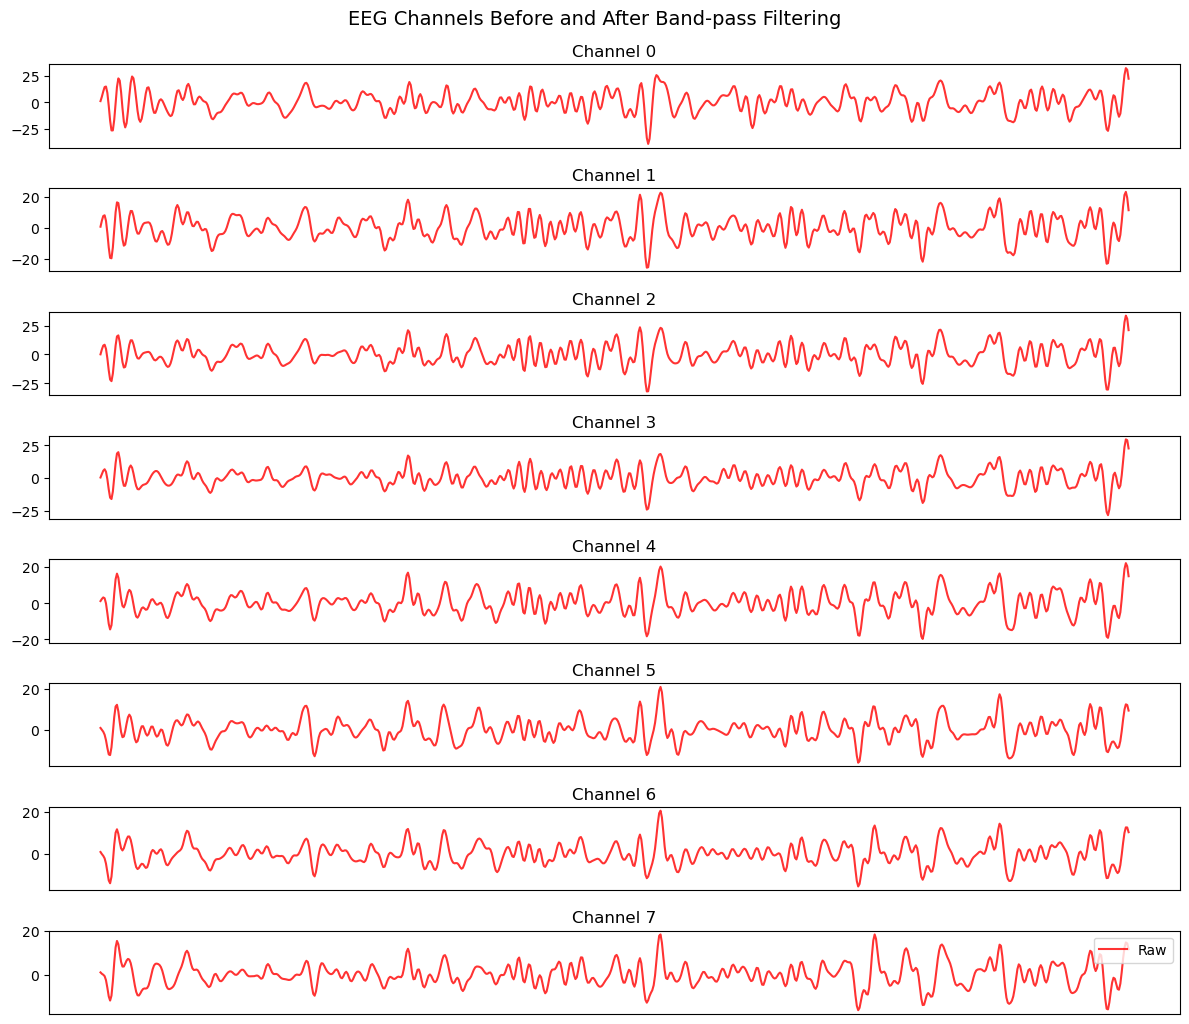

In [8]:
plt.figure(figsize=(12, 10))
for i in range(readings.shape[1]):
    plt.subplot(8, 1, i+1)
    plt.plot(filtered_readings[:750, i], color='red', alpha=0.8, label='Filtered')
    plt.title(f"Channel {i}")
    plt.xticks([])
    plt.tight_layout()

plt.legend(['Raw', 'Filtered'], loc='upper right')
plt.suptitle("EEG Channels Before and After Band-pass Filtering", fontsize=14, y=1.02)
plt.show()



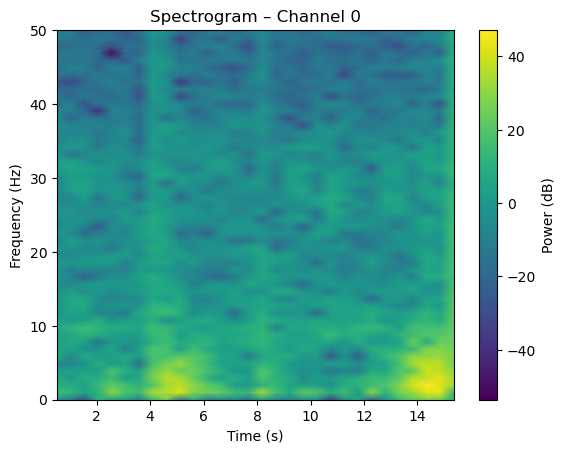

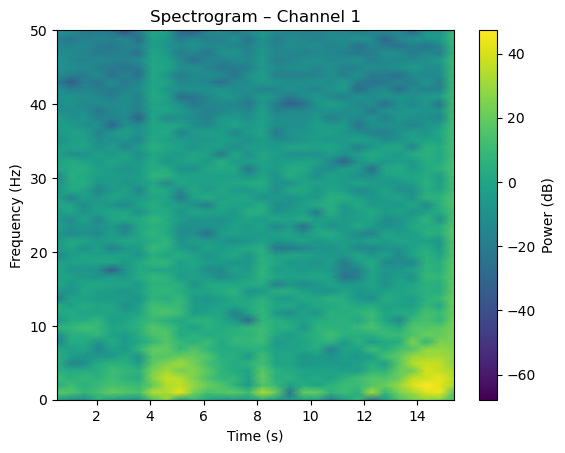

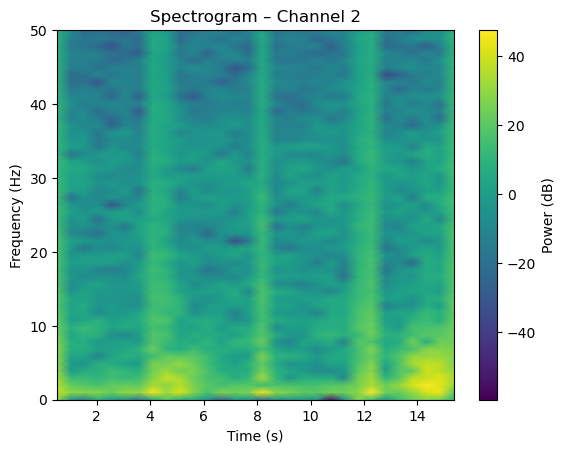

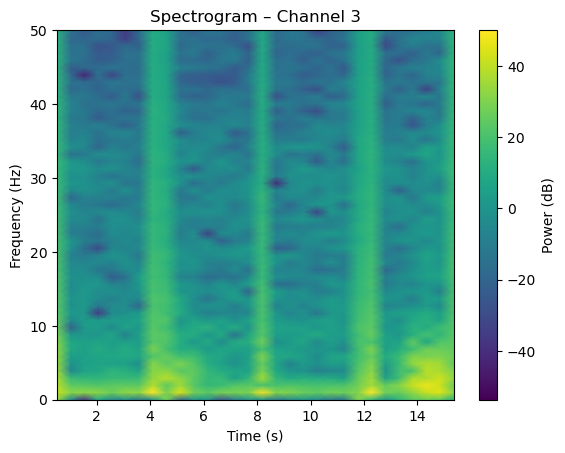

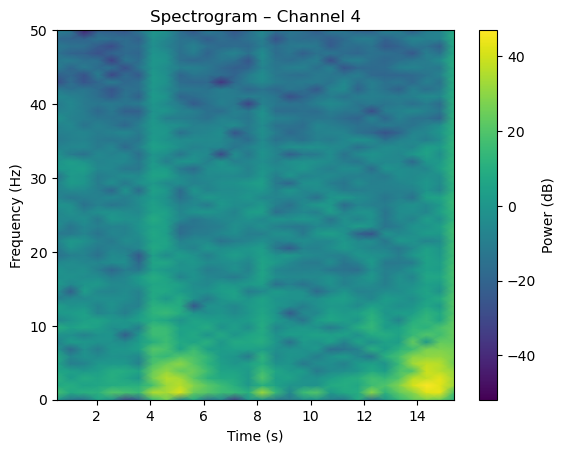

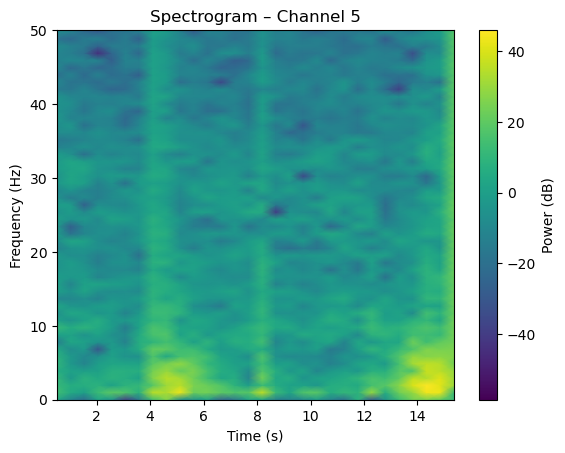

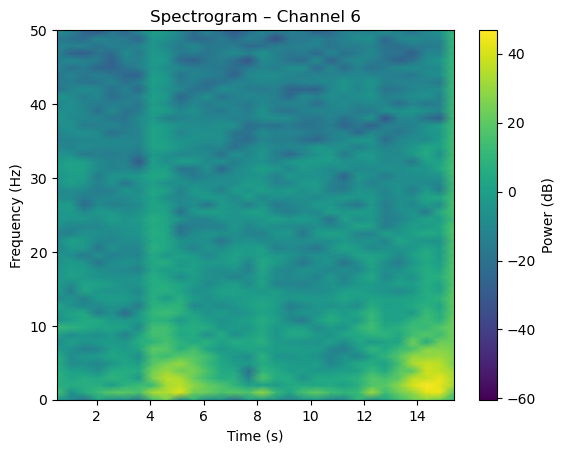

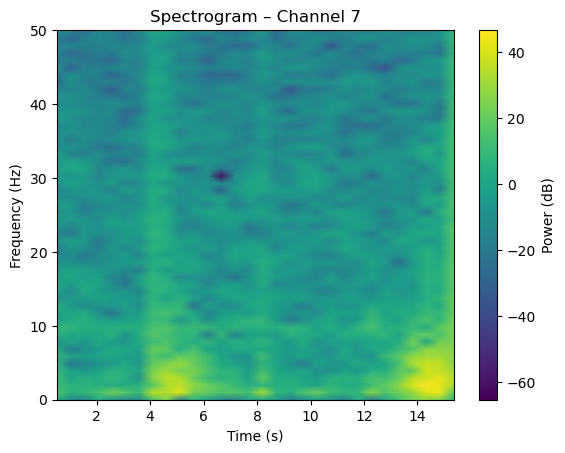

In [9]:
from scipy.signal import spectrogram

ch = 0
for i in range(readings.shape[1]):
    f, t, Sxx = spectrogram(readings[4000:8000, i], fs, nperseg=256, noverlap=128)
    plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
    plt.title(f"Spectrogram – Channel {i}")
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.ylim(0, 50)
    plt.colorbar(label='Power (dB)')
    plt.show()




filtered_readings shape: (272274, 8)
Creating RawArray with float64 data, n_channels=8, n_times=272274
    Range : 0 ... 272273 =      0.000 ...  1089.092 secs
Ready.
Fitting ICA...
Fitting ICA to data using 8 channels (please be patient, this may take a while)


C:\Users\Shivansh Sharma\AppData\Local\Temp\ipykernel_316\1324679270.py:21: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_mne)


Selecting by number: 8 components
Fitting ICA took 2.0s.


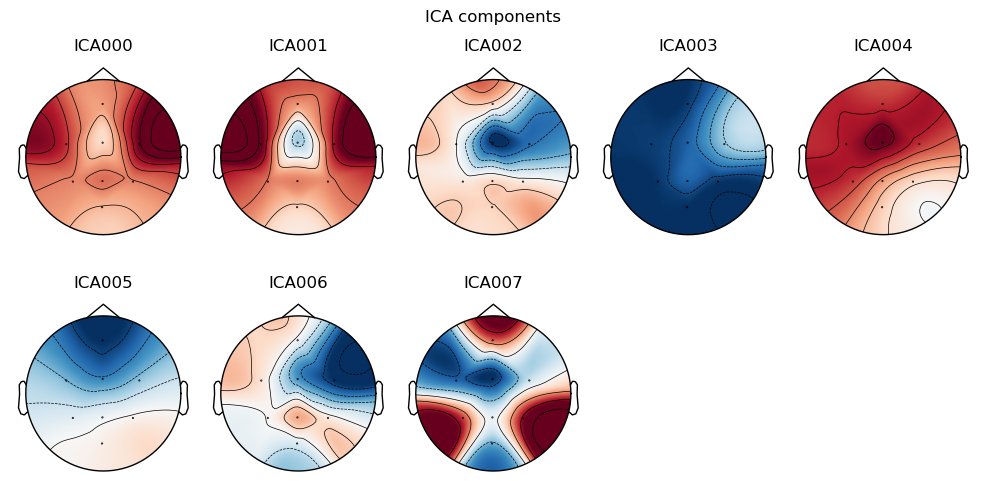

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 1 ICA component
    Projecting back using 8 PCA components
filtered_clean shape: (272274, 8)


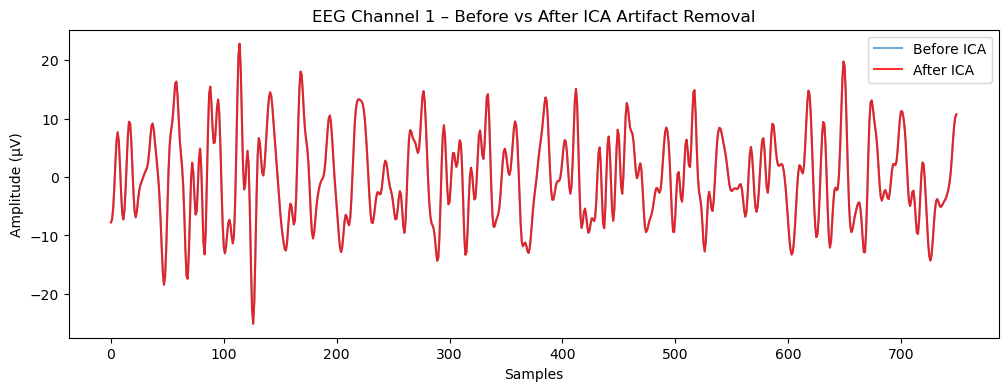

In [10]:
import mne


fs = 250
# Use realistic EEG channel names if possible
ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
ch_types = ['eeg'] * 8
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)

print("filtered_readings shape:", filtered_readings.shape)
raw_mne = mne.io.RawArray(filtered_readings.T, info)

# ✅ Add montage to provide electrode positions
montage = mne.channels.make_standard_montage('standard_1020')
# montage = mne.channels.get_montage('standard_1020')

raw_mne.set_montage(montage)
# --- Run ICA ---
ica = mne.preprocessing.ICA(n_components=8, random_state=42, max_iter=500)
print("Fitting ICA...")
ica.fit(raw_mne)

# --- Visualize components safely ---
ica.plot_components()  # now works, shows scalp maps
# OR if you only want time-series of activations:
# ica.plot_sources(raw_mne)

# --- Optionally exclude components ---
ica.exclude = [0]  # change after visual inspection
raw_clean = ica.apply(raw_mne)

filtered_clean = raw_clean.get_data().T
print("filtered_clean shape:", filtered_clean.shape)

# --- Quick comparison ---
plt.figure(figsize=(12, 4))
plt.plot(filtered_readings[4250:5000, 0], label='Before ICA', alpha=0.6)
plt.plot(filtered_clean[4250:5000, 0], label='After ICA', color='red', alpha=0.8)
plt.title('EEG Channel 1 – Before vs After ICA Artifact Removal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.show()

In [11]:
# ===============================================================
# Multi-band EEG filtering for FBMSNet (9 bands)
# ===============================================================

from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

# Define 9 frequency bands
filter_bands = [
    (4, 8), (8, 12), (12, 16), (16, 20), (20, 24),
    (24, 28), (28, 32), (32, 36), (36, 40)
]

fs = 250
n_bands = len(filter_bands)
n_channels = filtered_readings.shape[1]
n_samples = filtered_readings.shape[0]

filtered_multiband = np.zeros((n_bands, n_channels, n_samples))

# Apply filter for each band and channel
for b_idx, (low, high) in enumerate(filter_bands):
    for ch_idx in range(n_channels):
        filtered_multiband[b_idx, ch_idx, :] = bandpass_filter(
            filtered_readings[:, ch_idx], low, high, fs
        )

print("filtered_multiband shape:", filtered_multiband.shape)
# Should print: (9, 8, total_samples)


filtered_multiband shape: (9, 8, 272274)


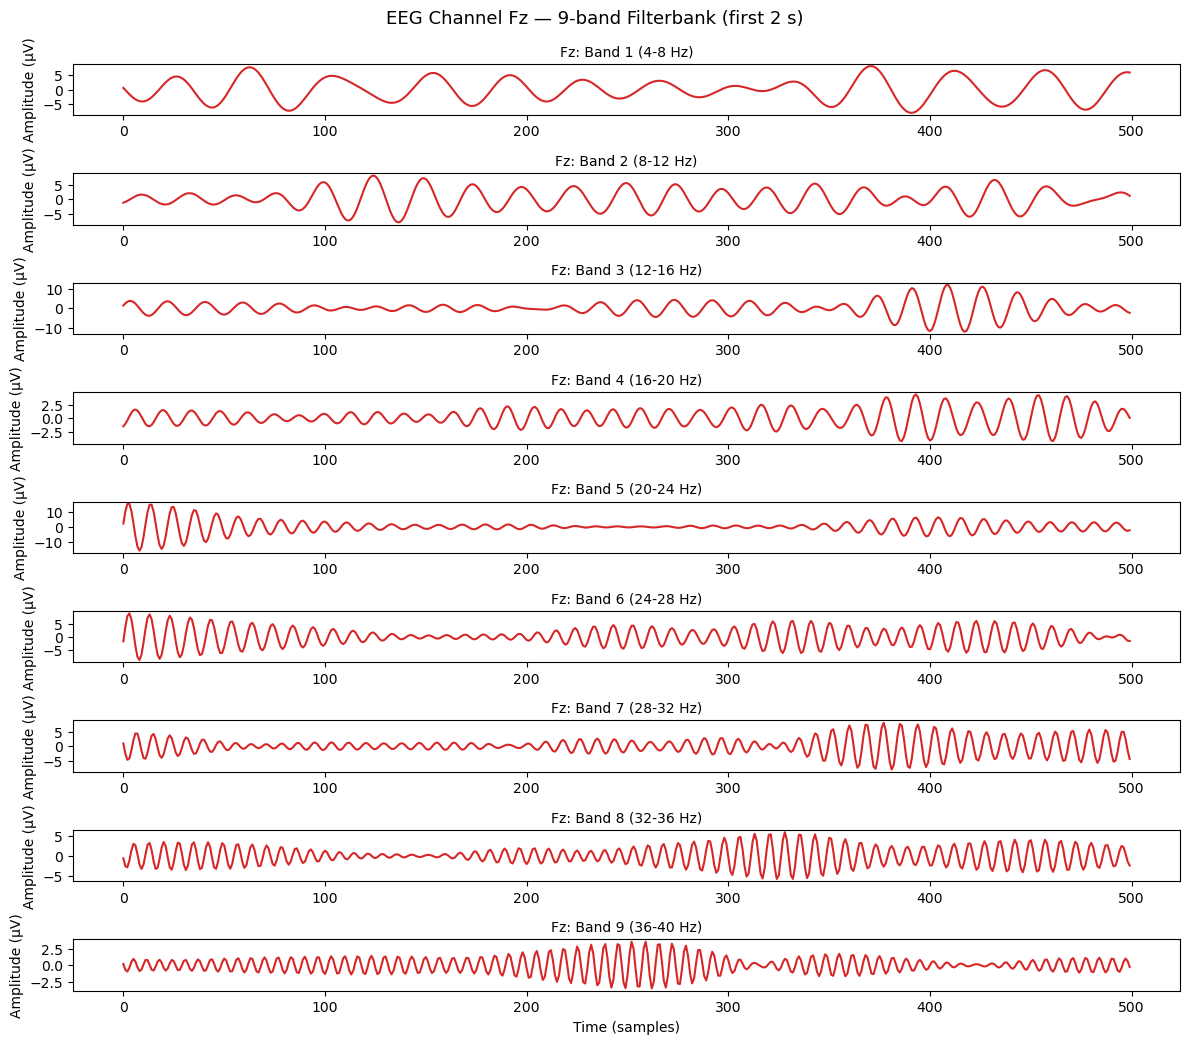

In [12]:
# ===============================================================
# ✅ Verification: visualize 9 frequency bands for one EEG channel
# ===============================================================
import matplotlib.pyplot as plt

# Choose one channel (0 = Fz, 1 = C3, etc.)
channel_idx = 0
channel_name = ch_names[channel_idx] if 'ch_names' in locals() else f"Ch {channel_idx}"

# Choose a short time segment (e.g., first 2 seconds)
fs = 250
start = 0
end = 2 * fs  # 2 seconds

plt.figure(figsize=(12, 10))
for b_idx, (low, high) in enumerate(filter_bands):
    plt.subplot(n_bands, 1, b_idx + 1)
    plt.plot(filtered_multiband[b_idx, channel_idx, start:end], color='tab:red')
    plt.title(f"{channel_name}: Band {b_idx+1} ({low}-{high} Hz)", fontsize=10)
    plt.ylabel('Amplitude (µV)')
    plt.tight_layout()

plt.xlabel("Time (samples)")
plt.suptitle(f"EEG Channel {channel_name} — 9-band Filterbank (first 2 s)", y=1.02, fontsize=13)
plt.show()


In [13]:

scaler = StandardScaler()
eeg_norm = scaler.fit_transform(filtered_readings)  # shape: (n_samples, 8)

print("eeg_norm shape:", eeg_norm)

eeg_norm shape: [[ 0.0191773  -0.00059467 -0.00110654 ...  0.00690228  0.01066965
   0.02371172]
 [ 0.20679983  0.12037491  0.06097871 ...  0.08954588  0.08709114
   0.09691747]
 [ 0.38261756  0.20623995  0.10763748 ...  0.13865649  0.1350873
   0.14686015]
 ...
 [ 0.27715945  0.17973598  0.07617719 ...  0.12278373  0.10185302
   0.12047721]
 [ 0.16996731  0.117739    0.04401429 ...  0.08442963  0.07111105
   0.0794448 ]
 [-0.01243618 -0.01350741 -0.00846693 ... -0.01813386 -0.01558187
  -0.0155206 ]]


In [14]:
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

In [15]:
def create_epochs_multiband(eeg_array, labels_array, stride, window, amp_thresh=150):
    """
    eeg_array shape: (n_bands, n_channels, n_samples)
    """
    X, y = [], []
    n_bands, n_channels, n_samples = eeg_array.shape
    
    for start in range(0, n_samples - window, stride):
        end = start + window
        epoch_labels = labels_array[start:end]
        majority = np.bincount(epoch_labels).argmax()
        purity = np.mean(epoch_labels == majority)
        
        if purity >= 0.9:
            epoch = eeg_array[:, :, start:end]  # shape: (9, 8, 250)
            if np.max(np.abs(epoch)) < amp_thresh:
                X.append(epoch)
                y.append(majority)
    return np.array(X), np.array(y)


In [16]:
# train_idx = np.where(split == 'train')[0]
# test_idx  = np.where(split == 'test')[0]

# eeg_train, lbl_train = eeg_norm[train_idx], labels_encoded[train_idx]
# eeg_test,  lbl_test  = eeg_norm[test_idx],  labels_encoded[test_idx]
# print("Train samples:", eeg_train.shape[0])
# print("Test samples :", eeg_test.shape[0])

In [17]:
window_sec = 1
window_size = fs * window_sec          # 250 samples per 1 s
train_stride = window_size // 2        # 50 % overlap
test_stride  = window_size             # no overlap
amp_thresh = 150   

# Convert flat EEG back to subject indices
train_idx = np.where(split == 'train')[0]
test_idx  = np.where(split == 'test')[0]

# Create epochs using multi-band data
X_train, y_train = create_epochs_multiband(
    filtered_multiband[:, :, train_idx],
    labels_encoded[train_idx],
    stride=train_stride,
    window=window_size
)

X_test, y_test = create_epochs_multiband(
    filtered_multiband[:, :, test_idx],
    labels_encoded[test_idx],
    stride=test_stride,
    window=window_size
)

print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)


Train epochs: (1490, 9, 8, 250) Test epochs: (167, 9, 8, 250)


In [18]:
def normalize_epoch_multiband(epoch):
    # epoch shape: (9, 8, 250)
    mean = epoch.mean(axis=(1, 2), keepdims=True)
    std = epoch.std(axis=(1, 2), keepdims=True) + 1e-8
    return (epoch - mean) / std

X_train = np.array([normalize_epoch_multiband(e) for e in X_train])
X_test  = np.array([normalize_epoch_multiband(e) for e in X_test])

# --- Reshape for CTNet ---
# X_train_ctnet = np.transpose(X_train, (0, 2, 1))  # (N, 8, 250)
# X_test_ctnet  = np.transpose(X_test,  (0, 2, 1))


print("CTNet train shape:", X_train.shape)
print("CTNet test shape:", X_test.shape)

CTNet train shape: (1490, 9, 8, 250)
CTNet test shape: (167, 9, 8, 250)


In [19]:
np.save("X_train_fbmsnet.npy", X_train)
np.save("y_train_fbmsnet.npy", y_train)
np.save("X_test_fbmsnet.npy",  X_test)
np.save("y_test_fbmsnet.npy",  y_test)
